# SS3 Part B: Applying the Concentration Risk Model to Real Client Data

This notebook applies the model selected in SS2 (XGBoost, see `experiments/results/Comparison.MD`) to STADIOEquities' real client data extract, received for SS3. The SS2 pipeline was built and validated on a public proxy dataset (SEC Form 13F institutional holdings); this notebook adapts that validated methodology to the client's own portfolio, transaction, and complaint data.

**Sections:**
1. Dataset Loading
2. Dataset Preprocessing
3. Model Training
4. Model Validation
5. Results Visualisation

In [44]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc




## 1. Dataset Loading

In [45]:
DATA_DIR = "../data/raw/client_extract"

client_info = pd.read_csv(f"{DATA_DIR}/table1_client_account_information.csv", dtype={"client_id": str})
holdings = pd.read_csv(f"{DATA_DIR}/table2_portfolio_holdings.csv", dtype={"client_id": str})
transactions = pd.read_csv(f"{DATA_DIR}/table3_transaction_history.csv", dtype={"client_id": str})
complaints = pd.read_csv(f"{DATA_DIR}/table4_support_complaint_history.csv", dtype={"client_id": str})

print("table1_client_account_information:", client_info.shape)
print("table2_portfolio_holdings:        ", holdings.shape)
print("table3_transaction_history:       ", transactions.shape)
print("table4_support_complaint_history: ", complaints.shape)

table1_client_account_information: (419, 7)
table2_portfolio_holdings:         (45660, 9)
table3_transaction_history:        (4175, 10)
table4_support_complaint_history:  (130, 7)


In [46]:
for name, df in [
    ("table1_client_account_information", client_info), ("table2_portfolio_holdings", holdings), ("table3_transaction_history", transactions), ("table4_support_complaint_history", complaints),]:
    
    print(f"\n{name}")
    print(df.dtypes)
    print("\nnulls:\n", df.isna().sum()[df.isna().sum() > 0])


table1_client_account_information
client_id                     str
client_age                float64
account_open_date             str
client_province               str
stated_risk_appetite          str
stated_investment_goal        str
account_status                str
dtype: object

nulls:
 client_age                 3
stated_investment_goal    14
dtype: int64

table2_portfolio_holdings
client_id                          str
snapshot_date                      str
instrument_ticker                  str
exchange                           str
instrument_name                    str
sector                             str
quantity_held                  float64
market_value_of_holding_zar    float64
total_portfolio_value_zar      float64
dtype: object

nulls:
 Series([], dtype: int64)

table3_transaction_history
client_id                    str
transaction_id               str
transaction_date             str
transaction_type             str
order_type                   str
instrument_tic

### Instance counts

| Table | Rows | Grain |
|---|---|---|
| `table1_client_account_information` | 419 | one row per client |
| `table2_portfolio_holdings` | 45,660 | one row per client-instrument-month (12 monthly snapshots to 31 Aug 2026) |
| `table3_transaction_history` | 4,175 | one row per executed buy/sell |
| `table4_support_complaint_history` | 130 | one row per complaint/support ticket |

Missing values confirm the data quality notes in the extract's README: `client_age` (3 missing) and `stated_investment_goal` (14 missing) in `table1`; `complaint_category` (85 missing, i.e. only 45/130 = 34.6% categorised) and `related_instrument_ticker` (84 missing) in `table4`. `table2` and `table3` show no null values in this pass, though the README notes casing, whitespace, duplicate-record, and date-format issues that do not surface as nulls and are investigated in Dataset Preprocessing below.

### Classes and class imbalance

This dataset does not arrive with a pre-built label. The outcome of interest is whether a client's **observed portfolio concentration contradicts their stated risk appetite** (e.g. a client who states a low risk appetite but holds a highly concentrated position), which the data provider has indicated is over-represented among suitability complaints in `table4_support_complaint_history`.

The label is a binary classification target (flagged / not flagged), constructed in Dataset Preprocessing below from `hhi` (75th-percentile threshold, 0.250) and `stated_risk_appetite`, and validated against real suitability complaints in `table4_support_complaint_history`.

**Class balance: 401 negative (95.93%) / 17 positive (4.07%)**, out of 418 clients. This figure is computed from the label constructed in section 2.4 below; it is stated here because class imbalance is part of what Dataset Loading is expected to report, and preprocessing (including the label construction and its validation against real complaint data) follows in the next section. This is a substantial imbalance, consistent with concentration-driven risk being a minority outcome among this client base, and is handled in Model Training below via class weighting.

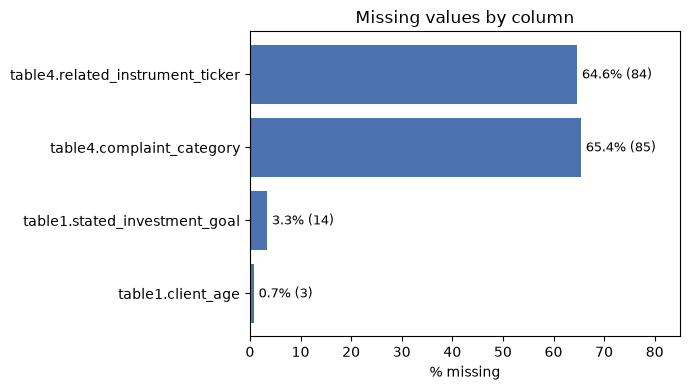

In [47]:
missing_summary = pd.DataFrame([
    {"table": "table1", "column": "client_age", "missing": 3, "total": 419},
    {"table": "table1", "column": "stated_investment_goal", "missing": 14, "total": 419},
    {"table": "table4", "column": "complaint_category", "missing": 85, "total": 130},
    {"table": "table4", "column": "related_instrument_ticker", "missing": 84, "total": 130},
])
missing_summary["pct_missing"] = missing_summary["missing"] / missing_summary["total"] * 100
missing_summary["label"] = missing_summary["table"] + "." + missing_summary["column"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(missing_summary["label"], missing_summary["pct_missing"], color="#4C72B0")
for bar, pct, n in zip(bars, missing_summary["pct_missing"], missing_summary["missing"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}% ({n})", va="center", fontsize=9)

ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
ax.set_xlim(0, max(missing_summary["pct_missing"]) * 1.3)
fig.tight_layout()
plt.savefig("missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Dataset Preprocessing

### 2.1 Data quality diagnostics

Before cleaning, each table is inspected for the issues the extract's README flags: inconsistent casing/whitespace in categorical and free-text fields, duplicate records, implausible values, and inconsistent date formats.

In [48]:
categorical_cols = {
    "table1_client_account_information": ["client_province", "stated_risk_appetite", "stated_investment_goal", "account_status"],
    "table2_portfolio_holdings": ["exchange", "sector"],
    "table3_transaction_history": ["transaction_type", "order_type", "exchange"],
    "table4_support_complaint_history": ["complaint_category", "resolution_outcome"],
}

dfs = {
    "table1_client_account_information": client_info,
    "table2_portfolio_holdings": holdings,
    "table3_transaction_history": transactions,
    "table4_support_complaint_history": complaints,
}

for table_name, cols in categorical_cols.items():
    df = dfs[table_name]
    print(f"\n{table_name}")
    for col in cols:
        uniques = df[col].dropna().unique()
        print(f"  {col} ({len(uniques)} unique): {sorted(uniques.tolist())[:15]}")


table1_client_account_information
  client_province (11 unique): [' GP ', 'EC', 'FS', 'GP', 'KZN', 'LP', 'MP', 'NC', 'NW', 'WC', 'wc']
  stated_risk_appetite (8 unique): [' High ', ' Moderate ', 'High', 'LOW', 'Low', 'MODERATE', 'Moderate', 'high']
  stated_investment_goal (8 unique): [' Long-term growth ', ' Short-term trading ', 'Education saving', 'Income generation', 'Long-term growth', 'Retirement saving', 'Short-term trading', 'Wealth preservation']
  account_status (4 unique): [' Active ', 'Active', 'Closed', 'Dormant']

table2_portfolio_holdings
  exchange (3 unique): ['JSE', 'NASDAQ', 'NYSE']
  sector (10 unique): ['Consumer Discretionary', 'Consumer Staples', 'Diversified', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Materials', 'Technology', 'Telecommunications']

table3_transaction_history
  transaction_type (2 unique): ['Buy', 'Sell']
  order_type (2 unique): ['Manual', 'Recurring/Auto-invest']
  exchange (3 unique): ['JSE', 'NASDAQ', 'NYSE']

table4_support_co

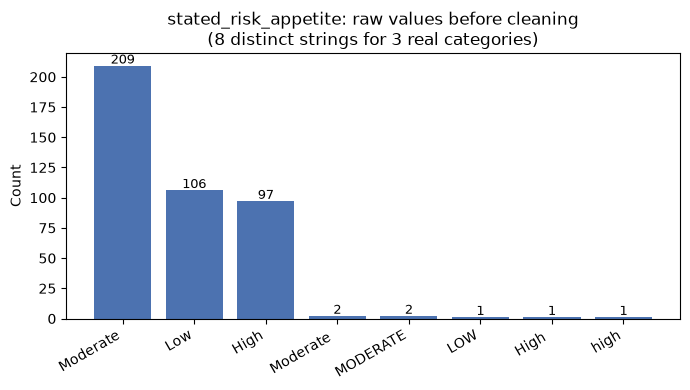

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))
raw_counts = client_info["stated_risk_appetite"].value_counts()
bars = ax.bar(raw_counts.index, raw_counts.values, color="#4C72B0")
for bar, val in zip(bars, raw_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 2, str(val), ha="center", fontsize=9)

ax.set_ylabel("Count")
ax.set_title("stated_risk_appetite: raw values before cleaning\n(8 distinct strings for 3 real categories)")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.savefig("raw_categorical_fragmentation.png", dpi=150, bbox_inches="tight")
plt.show()

- Categorical inspection shows inconsistent casing and stray whitespace concentrated in `table1_client_account_information` (`client_province`, `stated_risk_appetite`, `stated_investment_goal`, `account_status`), for example `' GP '` / `'wc'` vs `'WC'`, and `'LOW'` / `'Low'` vs `' High '`. Categorical fields in `table2` and `table3` are already clean. 
- Duplicates, implausible numeric values, and date format consistency are checked next.

In [50]:
for table_name, df in dfs.items():
    n_full_dupes = df.duplicated().sum()
    print(f"{table_name}: {n_full_dupes} fully duplicated rows")

print("\ntable3 duplicate transaction_id:", transactions["transaction_id"].duplicated().sum())
print("table4 duplicate complaint_id:  ", complaints["complaint_id"].duplicated().sum())
print("table2 duplicate (client_id, snapshot_date, instrument_ticker):",
      holdings.duplicated(subset=["client_id", "snapshot_date", "instrument_ticker"]).sum())

table1_client_account_information: 1 fully duplicated rows
table2_portfolio_holdings: 0 fully duplicated rows
table3_transaction_history: 0 fully duplicated rows
table4_support_complaint_history: 0 fully duplicated rows

table3 duplicate transaction_id: 0
table4 duplicate complaint_id:   0
table2 duplicate (client_id, snapshot_date, instrument_ticker): 0


In [51]:
print("client_age range:", client_info["client_age"].min(), "to", client_info["client_age"].max())
print("clients with age < 18 or > 100:", ((client_info["client_age"] < 18) | (client_info["client_age"] > 100)).sum())

print("\nquantity_held <= 0:", (holdings["quantity_held"] <= 0).sum())
print("market_value_of_holding_zar < 0:", (holdings["market_value_of_holding_zar"] < 0).sum())
print("total_portfolio_value_zar < market_value_of_holding_zar:",
      (holdings["total_portfolio_value_zar"] < holdings["market_value_of_holding_zar"]).sum())

print("\ntransaction quantity <= 0:", (transactions["quantity"] <= 0).sum())
print("price_per_unit_zar <= 0:", (transactions["price_per_unit_zar"] <= 0).sum())
print("transaction_value_zar mismatch (> 1 ZAR off from quantity * price):",
      (abs(transactions["transaction_value_zar"] - transactions["quantity"] * transactions["price_per_unit_zar"]) > 1).sum())

client_age range: 18.0 to 134.45
clients with age < 18 or > 100: 1

quantity_held <= 0: 0
market_value_of_holding_zar < 0: 0
total_portfolio_value_zar < market_value_of_holding_zar: 0

transaction quantity <= 0: 0
price_per_unit_zar <= 0: 0
transaction_value_zar mismatch (> 1 ZAR off from quantity * price): 0


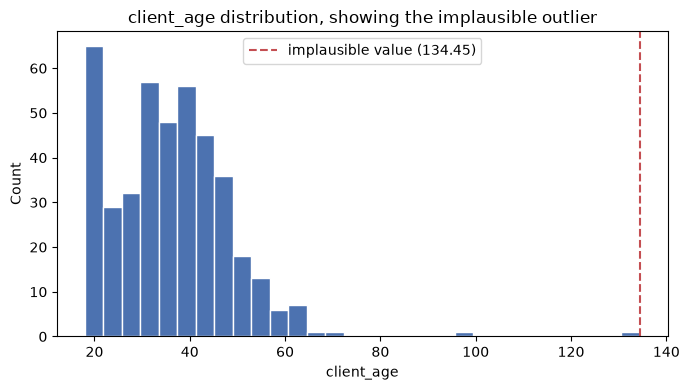

In [52]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(client_info["client_age"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(134.45, color="#C44E52", linestyle="--", linewidth=1.5, label="implausible value (134.45)")
ax.set_xlabel("client_age")
ax.set_ylabel("Count")
ax.set_title("client_age distribution, showing the implausible outlier")
ax.legend()
fig.tight_layout()
plt.savefig("client_age_outlier.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
for col, df, name in [
    ("account_open_date", client_info, "table1"),
    ("snapshot_date", holdings, "table2"),
    ("transaction_date", transactions, "table3"),
    ("date_logged", complaints, "table4"),
]:
    sample = df[col].dropna().astype(str).sample(min(10, len(df)), random_state=42).tolist()
    print(f"{name}.{col} sample formats: {sample}")

table1.account_open_date sample formats: ['2024-11-04', '2020-08-02', '2022-12-11', '2024-01-19', '2025-01-16', '2023-03-20', '2022-04-10', '2023-07-24', '2019-03-31', '2022-07-15']
table2.snapshot_date sample formats: ['2/28/2026', '4/30/2026', '2/28/2026', '10/31/2025', '8/31/2026', '11/30/2025', '6/30/2026', '5/31/2026', '7/31/2026', '3/31/2026']
table3.transaction_date sample formats: ['2025-10-24 12:57:05', '2026-06-23 16:24:13', '2026-05-27 11:33:34', '2026-06-04 12:25:52', '2026-07-14 14:40:06', '2026-06-26 14:11:29', '2026-03-13 13:18:30', '2026-06-08 15:30:09', '2025-10-09 15:49:21', '2026-07-07 11:05:06']
table4.date_logged sample formats: ['2025-08-02', '2025-12-12', '2026-03-20', '2026-08-12', '2026-06-26', '2025-12-08', '2026-05-06', '2026-06-14', '2026-05-13', '2025-11-08']


### Diagnostic findings

- **Duplicates**: 1 fully duplicated row in `table1_client_account_information`; no duplicates in `table2`, `table3`, or `table4` (checked on natural keys `transaction_id`, `complaint_id`, and `(client_id, snapshot_date, instrument_ticker)`).
- **Implausible values**: 1 client in `table1` has `client_age` of 134.45, outside a plausible 18-100 range for a living client and clearly a data-capture error. No implausible values found in `table2` or `table3` (all quantities and values are positive, and `transaction_value_zar` is internally consistent with `quantity * price_per_unit_zar`).
- **Inconsistent casing/whitespace**: concentrated in `table1`'s categorical columns (`client_province`, `stated_risk_appetite`, `stated_investment_goal`, `account_status`), e.g. `' GP '` / `'wc'` vs `'WC'`, `'LOW'` vs `' High '`.
- **Inconsistent date formats**: `table2.snapshot_date` is stored as `M/D/YYYY` (e.g. `2/28/2026`), while `table1.account_open_date`, `table3.transaction_date`, and `table4.date_logged` are all `yyyy-MM-dd` (or `yyyy-MM-dd HH:mm:ss` for the transaction timestamp).

These are addressed below: `table2` and `table3` categoricals need no cleaning; `table1` is cleaned for casing/whitespace, the duplicate row, and the implausible age; all date columns are parsed to a consistent `datetime` type.

In [54]:
client_info_clean = client_info.drop_duplicates().copy()

for col in ["client_province", "stated_risk_appetite", "stated_investment_goal", "account_status"]:
    client_info_clean[col] = client_info_clean[col].str.strip().str.title()

# stated_risk_appetite and client_province .title() gives inconsistent casing for acronyms (e.g. province codes); fix explicitly
client_info_clean["client_province"] = client_info_clean["client_province"].str.upper()
client_info_clean["stated_risk_appetite"] = client_info_clean["stated_risk_appetite"].str.capitalize()

# implausible age: treat as missing rather than dropping the client (the client still has holdings/transaction/complaint records used downstream)
implausible_age_mask = (client_info_clean["client_age"] < 18) | (client_info_clean["client_age"] > 100)
print("Implausible ages set to NaN:", implausible_age_mask.sum())
client_info_clean.loc[implausible_age_mask, "client_age"] = np.nan

client_info_clean["account_open_date"] = pd.to_datetime(client_info_clean["account_open_date"], format="%Y-%m-%d")

print("\nBefore:", client_info.shape, "\nAfter:", client_info_clean.shape)
for col in ["client_province", "stated_risk_appetite", "stated_investment_goal", "account_status"]:
    print(f"{col}: {sorted(client_info_clean[col].dropna().unique().tolist())}")

Implausible ages set to NaN: 1

Before: (419, 7) 
After: (418, 7)
client_province: ['EC', 'FS', 'GP', 'KZN', 'LP', 'MP', 'NC', 'NW', 'WC']
stated_risk_appetite: ['High', 'Low', 'Moderate']
stated_investment_goal: ['Education Saving', 'Income Generation', 'Long-Term Growth', 'Retirement Saving', 'Short-Term Trading', 'Wealth Preservation']
account_status: ['Active', 'Closed', 'Dormant']


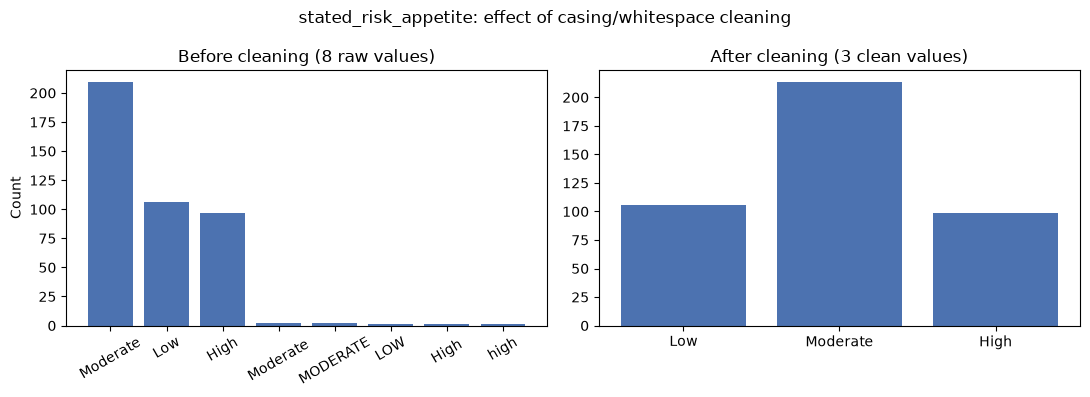

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

raw_counts = client_info["stated_risk_appetite"].value_counts()
axes[0].bar(raw_counts.index, raw_counts.values, color="#4C72B0")
axes[0].set_title("Before cleaning (8 raw values)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Count")

clean_counts = client_info_clean["stated_risk_appetite"].value_counts().reindex(["Low", "Moderate", "High"])
axes[1].bar(clean_counts.index, clean_counts.values, color="#4C72B0")
axes[1].set_title("After cleaning (3 clean values)")

fig.suptitle("stated_risk_appetite: effect of casing/whitespace cleaning")
fig.tight_layout()
plt.savefig("cleaning_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
holdings_clean = holdings.copy()
holdings_clean["snapshot_date"] = pd.to_datetime(holdings_clean["snapshot_date"], format="%m/%d/%Y")

transactions_clean = transactions.copy()
transactions_clean["transaction_date"] = pd.to_datetime(transactions_clean["transaction_date"], format="%Y-%m-%d %H:%M:%S")

complaints_clean = complaints.copy()
complaints_clean["date_logged"] = pd.to_datetime(complaints_clean["date_logged"], format="%Y-%m-%d")

print("snapshot_date range:", holdings_clean["snapshot_date"].min(), "to", holdings_clean["snapshot_date"].max())
print("unique snapshot dates:", holdings_clean["snapshot_date"].nunique())
print("\ntransaction_date range:", transactions_clean["transaction_date"].min(), "to", transactions_clean["transaction_date"].max())
print("\ndate_logged range:", complaints_clean["date_logged"].min(), "to", complaints_clean["date_logged"].max())

snapshot_date range: 2025-09-30 00:00:00 to 2026-08-31 00:00:00
unique snapshot dates: 12

transaction_date range: 2025-09-03 09:49:20 to 2026-08-31 16:52:02

date_logged range: 2025-07-29 00:00:00 to 2026-08-30 00:00:00


In [57]:
tickers_holdings = set(holdings_clean["instrument_ticker"].dropna().unique())
tickers_transactions = set(transactions_clean["instrument_ticker"].dropna().unique())
tickers_complaints = set(complaints_clean["related_instrument_ticker"].dropna().unique())

print("tickers in holdings:", len(tickers_holdings))
print("tickers in transactions:", len(tickers_transactions))
print("tickers in complaints:", len(tickers_complaints))

print("\ntransaction tickers not in holdings:", tickers_transactions - tickers_holdings)
print("complaint tickers not in holdings:", tickers_complaints - tickers_holdings)

# check for casing/whitespace variants within instrument_ticker itself
print("\nsample holdings tickers:", sorted(tickers_holdings)[:10])

# instrument_name consistency per ticker (should be 1:1)
name_map = holdings_clean.groupby("instrument_ticker")["instrument_name"].nunique()
print("\ntickers with >1 distinct instrument_name:", (name_map > 1).sum())
if (name_map > 1).sum() > 0:
    print(name_map[name_map > 1])

# sector consistency per ticker (should be 1:1)
sector_map = holdings_clean.groupby("instrument_ticker")["sector"].nunique()
print("\ntickers with >1 distinct sector:", (sector_map > 1).sum())

tickers in holdings: 47
tickers in transactions: 47
tickers in complaints: 28

transaction tickers not in holdings: set()
complaint tickers not in holdings: set()

sample holdings tickers: ['AAPL', 'ABG', 'AGL', 'AMZN', 'ANG', 'BHG', 'BRK.B', 'BTI', 'BVT', 'CLS']

tickers with >1 distinct instrument_name: 0

tickers with >1 distinct sector: 0


### 2.2 Concentration feature construction

Portfolio concentration features are computed per client per monthly snapshot, using the same definitions established in SS2's feature engineering methodology (`src/features/FeatureEngineering.MD`):

- `hhi`: Herfindahl-Hirschman Index of holding weights, Σ(weight²), where weight = `market_value_of_holding_zar` / `total_portfolio_value_zar`
- `top_holding_pct`: the largest single holding weight
- `num_holdings`: count of distinct instruments held
- `sector_hhi`: HHI computed on sector-level weights (holdings aggregated by `sector` first)
- `total_value`: `total_portfolio_value_zar` (already provided per row, constant within a client-date)

This dataset is monthly (12 snapshots per client), so features are computed at monthly grain.

In [58]:
holdings_clean["weight"] = holdings_clean["market_value_of_holding_zar"] / holdings_clean["total_portfolio_value_zar"]

def concentration_features(group):
    hhi = (group["weight"] ** 2).sum()
    top_holding_pct = group["weight"].max()
    num_holdings = group["instrument_ticker"].nunique()
    sector_weights = group.groupby("sector")["weight"].sum()
    sector_hhi = (sector_weights ** 2).sum()
    total_value = group["total_portfolio_value_zar"].iloc[0]
    return pd.Series({
        "hhi": hhi,
        "top_holding_pct": top_holding_pct,
        "num_holdings": num_holdings,
        "sector_hhi": sector_hhi,
        "total_value": total_value,
    })

portfolio_features = (
    holdings_clean.groupby(["client_id", "snapshot_date"])
    .apply(concentration_features, include_groups=False)
    .reset_index()
)

print(portfolio_features.shape)
print(portfolio_features.describe())
display_portfolio_features = portfolio_features.head().copy()
display_portfolio_features['client_id'] = [f"Client {i+1}" for i in range(len(display_portfolio_features))]
display_portfolio_features

(5016, 7)
             snapshot_date          hhi  top_holding_pct  num_holdings  \
count                 5016  5016.000000      5016.000000   5016.000000   
mean   2026-03-16 06:00:00     0.217834         0.314020      9.102871   
min    2025-09-30 00:00:00     0.068424         0.088808      1.000000   
25%    2025-12-23 06:00:00     0.123741         0.196735      7.000000   
50%    2026-03-15 12:00:00     0.171506         0.273764      9.000000   
75%    2026-06-07 12:00:00     0.250788         0.378585     11.000000   
max    2026-08-31 00:00:00     1.000000         1.000000     16.000000   
std                    NaN     0.152843         0.170208      3.406138   

        sector_hhi   total_value  
count  5016.000000  5.016000e+03  
mean      0.304652  6.328135e+04  
min       0.127188  3.970000e+02  
25%       0.209091  1.149067e+04  
50%       0.262842  2.643393e+04  
75%       0.344123  7.246447e+04  
max       1.000000  1.642626e+06  
std       0.155845  1.157365e+05  


,client_id,snapshot_date,hhi,top_holding_pct,num_holdings,sector_hhi,total_value
0,Client 1,2025-09-30,0.141536,0.235589,10.0,0.161301,66746.50
1,Client 2,2025-10-31,0.141199,0.222657,10.0,0.161926,72188.99
2,Client 3,2025-11-30,0.139529,0.229000,10.0,0.160991,69268.90
3,Client 4,2025-12-31,0.135823,0.212671,10.0,0.157431,65693.74
4,Client 5,2026-01-31,0.143433,0.236120,10.0,0.165372,72269.39


### 2.2b Behavioral feature: share of auto-invest activity

The extract's README flags `order_type` (`Manual` vs `Recurring/Auto-invest`) as the signal that separates deliberate concentration from passive accumulation, since roughly a third of clients use auto-invest. This is added as a sixth feature, `pct_autoinvest_value`: the share of a client's total transaction value (across the full observation window) executed via auto-invest, rather than manually. All 418 clients have transaction history, so this is computed for every client, with no missing values.

This is computed at the client level (not per snapshot), since trading behavior is a client characteristic rather than something that meaningfully changes month to month. It is deliberately kept separate from the label itself: concentration carries the same loss exposure whether it was built manually or through auto-invest, so the label (risk-appetite vs. observed concentration mismatch) is not adjusted by `order_type`. Instead, `pct_autoinvest_value` is included as a model feature, so the model and its feature importances can show empirically whether manually-built concentration predicts complaints more strongly than auto-invest-built concentration, rather than that being assumed upfront.

In [59]:
txn_value_by_client = transactions_clean.groupby("client_id")["transaction_value_zar"].sum()
autoinvest_value_by_client = (
    transactions_clean[transactions_clean["order_type"] == "Recurring/Auto-invest"]
    .groupby("client_id")["transaction_value_zar"].sum()
    .reindex(txn_value_by_client.index, fill_value=0)
)

pct_autoinvest = (autoinvest_value_by_client / txn_value_by_client).rename("pct_autoinvest_value").reset_index()

print("Clients with transaction history:", txn_value_by_client.shape[0], "/", client_info_clean.shape[0])
print("pct_autoinvest_value summary:")
print(pct_autoinvest["pct_autoinvest_value"].describe())

portfolio_features = portfolio_features.drop(columns=["pct_autoinvest_value"], errors="ignore").merge(
    pct_autoinvest, on="client_id", how="left"
)
missing_latest = portfolio_features.loc[
    portfolio_features["snapshot_date"] == portfolio_features["snapshot_date"].max(), "pct_autoinvest_value"
].isna().sum()
print("\nClients missing pct_autoinvest_value as of the latest snapshot:", missing_latest)

Clients with transaction history: 418 / 418
pct_autoinvest_value summary:
count    418.000000
mean       0.209431
std        0.328895
min        0.000000
25%        0.000000
50%        0.000000
75%        0.410417
max        1.000000
Name: pct_autoinvest_value, dtype: float64

Clients missing pct_autoinvest_value as of the latest snapshot: 0


### 2.3 Feature distributions and correlation

Before building the label, the five concentration features are inspected for distribution shape (to judge if any need transformation) and pairwise correlation, since correlated features affect how model feature importances should be interpreted later.

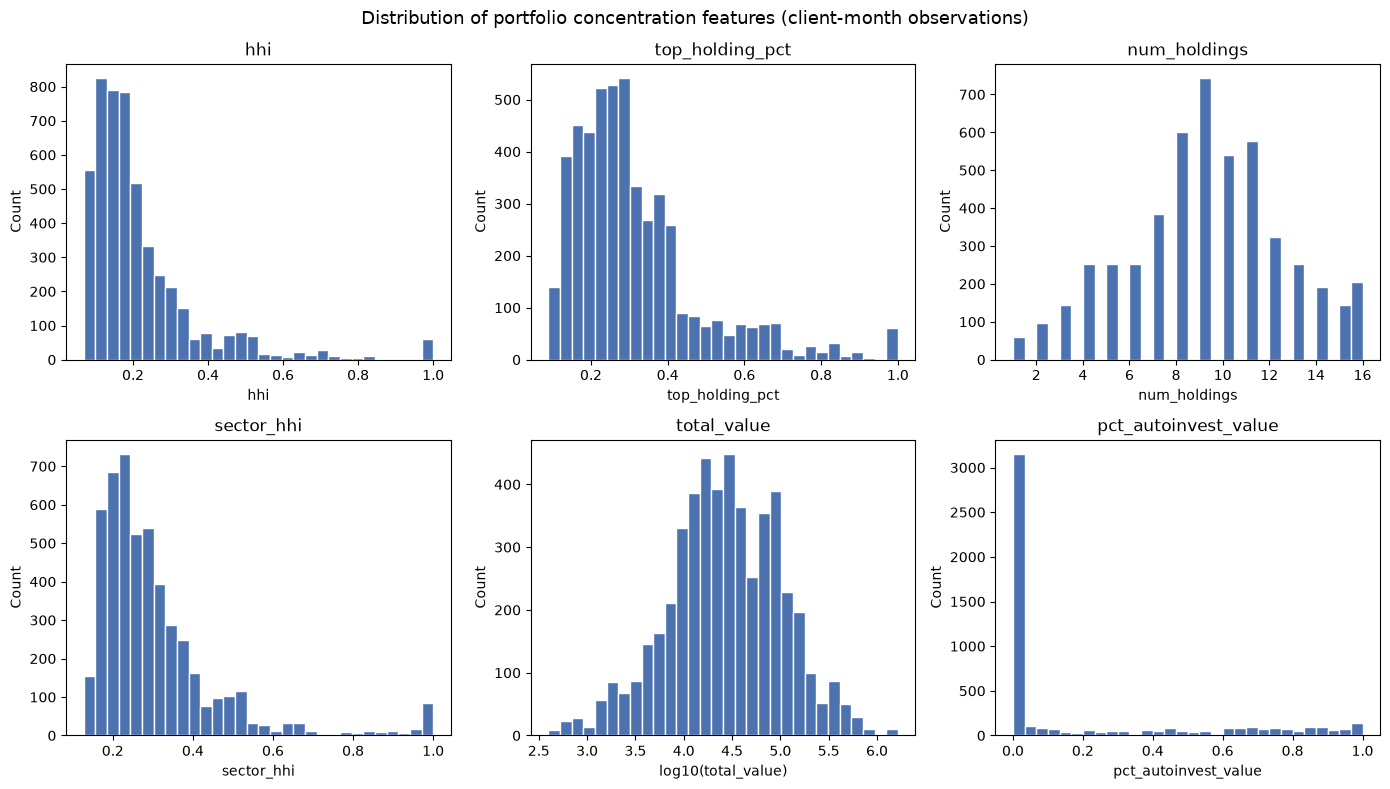

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ["hhi", "top_holding_pct", "num_holdings", "sector_hhi", "total_value", "pct_autoinvest_value"]
axes = axes.flatten()

for ax, col in zip(axes, features):
    data = portfolio_features[col].dropna()
    if col == "total_value":
        data = np.log10(data)
        ax.set_xlabel("log10(total_value)")
    else:
        ax.set_xlabel(col)
    ax.hist(data, bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Count")

fig.suptitle("Distribution of portfolio concentration features (client-month observations)", fontsize=13)
fig.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

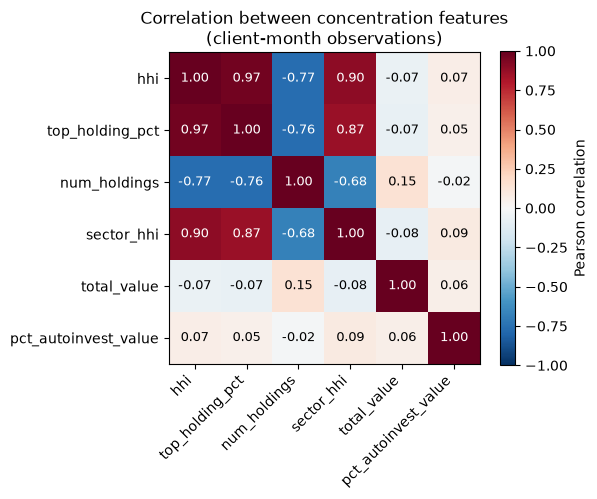

                        hhi  top_holding_pct  num_holdings  sector_hhi  \
hhi                   1.000            0.968        -0.766       0.897   
top_holding_pct       0.968            1.000        -0.762       0.866   
num_holdings         -0.766           -0.762         1.000      -0.677   
sector_hhi            0.897            0.866        -0.677       1.000   
total_value          -0.070           -0.074         0.145      -0.078   
pct_autoinvest_value  0.066            0.052        -0.018       0.089   

                      total_value  pct_autoinvest_value  
hhi                        -0.070                 0.066  
top_holding_pct            -0.074                 0.052  
num_holdings                0.145                -0.018  
sector_hhi                 -0.078                 0.089  
total_value                 1.000                 0.061  
pct_autoinvest_value        0.061                 1.000  


In [61]:
corr = portfolio_features[features].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr.iloc[i, j]) > 0.6 else "black", fontsize=9)

fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Correlation between concentration features\n(client-month observations)")
fig.tight_layout()
plt.savefig("feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(corr.round(3))

- Distributions are right-skewed for `hhi`, `top_holding_pct`, and `sector_hhi` (most clients moderately diversified, a smaller group heavily concentrated up to the maximum of 1.0), broadly symmetric for `num_holdings`, and right-skewed for `total_value` (log-scaled above for readability). `pct_autoinvest_value` is bimodal: a large spike at 0 (over half of clients have done no auto-invest trading at all) and a smaller spike near 1.0 (a minority trade almost exclusively via auto-invest), with the remainder spread fairly evenly between.

- The correlation matrix shows `hhi` and `top_holding_pct` are strongly correlated (r=0.97), and both correlate strongly with `sector_hhi` (r=0.90, r=0.87), expected, since a client's single largest holding often is their largest sector exposure too. `total_value` and `pct_autoinvest_value` are both close to uncorrelated with the four concentration measures and with each other (all |r| < 0.09), so both carry independent information rather than duplicating what the concentration measures already capture.

- This correlation structure matters for interpreting feature importance later: `hhi`, `top_holding_pct`, and `sector_hhi` are measuring overlapping aspects of the same underlying concentration, so no single one of them should be read in isolation when explaining a flagged client to the business. `pct_autoinvest_value`, by contrast, is independent of concentration itself, its value will be in explaining *why* a concentrated client got that way, not in predicting concentration.

### 2.4 Label construction: risk-appetite / concentration mismatch

The label identifies clients whose observed portfolio concentration contradicts their stated risk appetite specifically, clients who state a **Low** risk appetite but whose observed concentration is high. This is validated against real complaint outcomes in `table4_support_complaint_history` before being accepted as the target.

- Step 1: join each client's most recent concentration features to their stated risk appetite.
- Step 2: define "high observed concentration" using a threshold on `hhi`, chosen by inspecting the distribution above rather than picked arbitrarily.
- Step 3: validate check whether the mismatch group is actually over-represented among suitability-related complaints, as the data provider's README claims.

In [62]:
latest_features = (
    portfolio_features.sort_values("snapshot_date")
    .groupby("client_id")
    .tail(1)
    .merge(client_info_clean[["client_id", "stated_risk_appetite", "client_age", "client_province"]], on="client_id", how="left")
)

print(latest_features.shape)
print(latest_features["stated_risk_appetite"].value_counts())
print("\nhhi by stated_risk_appetite:")
print(latest_features.groupby("stated_risk_appetite")["hhi"].describe()[["count", "mean", "50%", "75%", "max"]])

(418, 11)
stated_risk_appetite
Moderate    213
Low         106
High         99
Name: count, dtype: int64

hhi by stated_risk_appetite:
                      count      mean       50%       75%  max
stated_risk_appetite                                          
High                   99.0  0.252940  0.202896  0.293087  1.0
Low                   106.0  0.187479  0.151408  0.215864  1.0
Moderate              213.0  0.217091  0.168733  0.248427  1.0


The group-level summary above needs a visual before interpreting it further, since the counter-intuitive mean comparison (Low risk-appetite clients showing lower average `hhi` than High) could otherwise be misread without seeing the full distribution and tail per group.

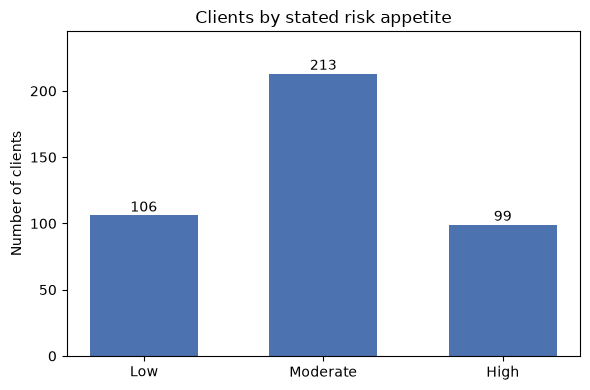

In [63]:
risk_order = ["Low", "Moderate", "High"]
counts = latest_features["stated_risk_appetite"].value_counts().reindex(risk_order)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(risk_order, counts.values, color="#4C72B0", width=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 3, str(val), ha="center", fontsize=10)

ax.set_ylabel("Number of clients")
ax.set_title("Clients by stated risk appetite")
ax.set_ylim(0, counts.max() * 1.15)
fig.tight_layout()
plt.savefig("risk_appetite_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

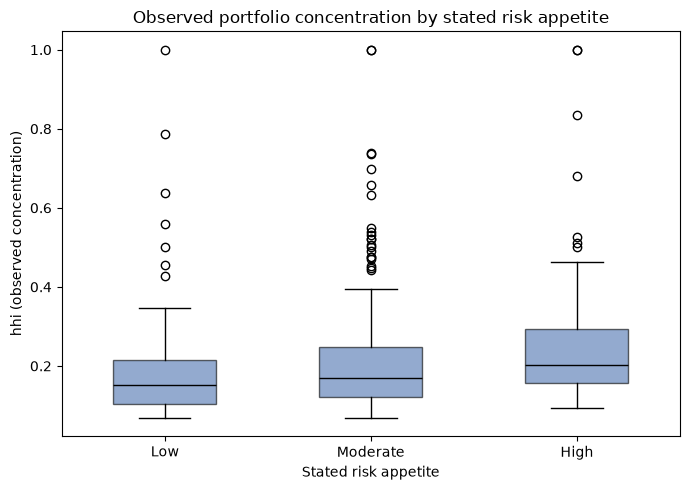

In [64]:
fig, ax = plt.subplots(figsize=(7, 5))
data_by_group = [latest_features.loc[latest_features["stated_risk_appetite"] == g, "hhi"] for g in risk_order]

bp = ax.boxplot(data_by_group, tick_labels=risk_order, patch_artist=True, widths=0.5)
for box in bp["boxes"]:
    box.set_facecolor("#4C72B0")
    box.set_alpha(0.6)
for median in bp["medians"]:
    median.set_color("black")

ax.set_ylabel("hhi (observed concentration)")
ax.set_xlabel("Stated risk appetite")
ax.set_title("Observed portfolio concentration by stated risk appetite")
fig.tight_layout()
plt.savefig("hhi_by_risk_appetite.png", dpi=150, bbox_inches="tight")
plt.show()

In [65]:
candidate_percentiles = [70, 75, 80, 90]
thresholds = {p: latest_features["hhi"].quantile(p / 100) for p in candidate_percentiles}

print("Candidate hhi thresholds:")
for p, t in thresholds.items():
    n_flagged = ((latest_features["stated_risk_appetite"] == "Low") & (latest_features["hhi"] > t)).sum()
    n_low = (latest_features["stated_risk_appetite"] == "Low").sum()
    print(f"  {p}th percentile (hhi > {t:.3f}): {n_flagged} / {n_low} Low-appetite clients flagged ({n_flagged/n_low:.1%})")

Candidate hhi thresholds:
  70th percentile (hhi > 0.226): 22 / 106 Low-appetite clients flagged (20.8%)
  75th percentile (hhi > 0.250): 17 / 106 Low-appetite clients flagged (16.0%)
  80th percentile (hhi > 0.279): 14 / 106 Low-appetite clients flagged (13.2%)
  90th percentile (hhi > 0.389): 7 / 106 Low-appetite clients flagged (6.6%)


In [66]:
suitability_categories = ["Unsuitable investment choice", "Concentration warning query"]

complaint_clients_any = set(complaints_clean["client_id"])
complaint_clients_suitability = set(
    complaints_clean.loc[complaints_clean["complaint_category"].isin(suitability_categories), "client_id"]
)

print("Clients with any complaint:", len(complaint_clients_any), "/", latest_features.shape[0])
print("Clients with a suitability-related (categorised) complaint:", len(complaint_clients_suitability))

print("\nValidation by candidate threshold:")
for p, t in thresholds.items():
    flagged = latest_features[(latest_features["stated_risk_appetite"] == "Low") & (latest_features["hhi"] > t)]
    low_not_flagged = latest_features[(latest_features["stated_risk_appetite"] == "Low") & (latest_features["hhi"] <= t)]

    flagged_ids = set(flagged["client_id"])
    not_flagged_ids = set(low_not_flagged["client_id"])

    n_flagged_complaints = len(flagged_ids & complaint_clients_suitability)
    n_not_flagged_complaints = len(not_flagged_ids & complaint_clients_suitability)

    flagged_rate = n_flagged_complaints / len(flagged_ids) if flagged_ids else 0
    not_flagged_rate = n_not_flagged_complaints / len(not_flagged_ids) if not_flagged_ids else 0
    overall_rate = len(complaint_clients_suitability) / latest_features.shape[0]

    print()
    print(p, "th percentile, n_flagged =", len(flagged_ids))
    print("  flagged rate:", round(flagged_rate * 100, 1), "% (", n_flagged_complaints, "/", len(flagged_ids), ")")
    print("  Low not-flagged rate:", round(not_flagged_rate * 100, 1), "% (", n_not_flagged_complaints, "/", len(not_flagged_ids), ")")
    print("  overall rate:", round(overall_rate * 100, 1), "%")

Clients with any complaint: 106 / 418
Clients with a suitability-related (categorised) complaint: 12

Validation by candidate threshold:

70 th percentile, n_flagged = 22
  flagged rate: 4.5 % ( 1 / 22 )
  Low not-flagged rate: 2.4 % ( 2 / 84 )
  overall rate: 2.9 %

75 th percentile, n_flagged = 17
  flagged rate: 5.9 % ( 1 / 17 )
  Low not-flagged rate: 2.2 % ( 2 / 89 )
  overall rate: 2.9 %

80 th percentile, n_flagged = 14
  flagged rate: 0.0 % ( 0 / 14 )
  Low not-flagged rate: 3.3 % ( 3 / 92 )
  overall rate: 2.9 %

90 th percentile, n_flagged = 7
  flagged rate: 0.0 % ( 0 / 7 )
  Low not-flagged rate: 3.0 % ( 3 / 99 )
  overall rate: 2.9 %


In [67]:
pd.set_option("display.max_colwidth", None)
suitability_examples = complaints_clean.loc[
    complaints_clean["complaint_category"].isin(suitability_categories),
    ["complaint_category", "complaint_text"]
]
print(suitability_examples.to_string())

               complaint_category                                                                                       complaint_text
0    Unsuitable investment choice            The app let me put my whole retirement pot into a single mining share without any warning
31   Unsuitable investment choice            The app let me put my whole retirement pot into a single mining share without any warning
32    Concentration warning query                         Why am I getting a warning about concentration when I only hold what I chose
36   Unsuitable investment choice            I was told this was suitable for a conservative investor and it has dropped forty percent
42   Unsuitable investment choice                    My entire balance is in one offshore tech share and I did not understand the risk
47   Unsuitable investment choice            I was told this was suitable for a conservative investor and it has dropped forty percent
61    Concentration warning query                      

In [68]:
print("Total complaints:", len(complaints_clean))
print("Unique complaint_text values:", complaints_clean["complaint_text"].nunique())
print()
unique_texts = complaints_clean["complaint_text"].value_counts()
print(unique_texts.to_string())

Total complaints: 130
Unique complaint_text values: 22

complaint_text
The app crashed midway through placing an order and I do not know if it went through                   12
I placed a sell order that never went through and I lost money as a result                             10
I requested a withdrawal eight days ago and the money has not arrived                                   9
The price shown on screen was not the price I was actually charged                                      9
Why am I getting a warning about concentration when I only hold what I chose                            7
I was told this was suitable for a conservative investor and it has dropped forty percent               7
My order executed at a much worse price than the one displayed                                          7
The app let me put my whole retirement pot into a single mining share without any warning               6
Locked out of my account and the verification SMS never arrives                  

In [69]:
complaint_text_to_category = {
    "The app crashed midway through placing an order and I do not know if it went through": "Platform or technical",
    "I placed a sell order that never went through and I lost money as a result": "Trade execution",
    "The price shown on screen was not the price I was actually charged": "Trade execution",
    "I requested a withdrawal eight days ago and the money has not arrived": "Withdrawal delay",
    "Why am I getting a warning about concentration when I only hold what I chose": "Concentration warning query",
    "My order executed at a much worse price than the one displayed": "Trade execution",
    "I was told this was suitable for a conservative investor and it has dropped forty percent": "Unsuitable investment choice",
    "Cannot log in since the update and support has not responded": "Account access",
    "My account was suspended without any notice or reason given": "Account access",
    "Recurring purchase went through twice in the same month": "Trade execution",
    "The app let me put my whole retirement pot into a single mining share without any warning": "Unsuitable investment choice",
    "Locked out of my account and the verification SMS never arrives": "Account access",
    "Nobody explained that holding one share only was dangerous for someone my age": "Unsuitable investment choice",
    "I do not understand the monthly charge that appeared on my statement": "Fees and charges",
    "Was charged a currency conversion fee that was never disclosed upfront": "Fees and charges",
    "I received a risk alert but no explanation of what I should do about it": "Concentration warning query",
    "Sold my shares to pay for something urgent and the funds are still not cleared": "Withdrawal delay",
    "The brokerage fee on my offshore trade was far higher than advertised": "Fees and charges",
    "The app says my portfolio is concentrated, what does that actually mean": "Concentration warning query",
    "My entire balance is in one offshore tech share and I did not understand the risk": "Unsuitable investment choice",
    "I lost most of my savings after putting everything into one stock and nobody warned me it was risky": "Unsuitable investment choice",
    "Withdrawal was reversed with no explanation given": "Withdrawal delay",
}

complaints_clean["complaint_category_derived"] = complaints_clean["complaint_text"].map(complaint_text_to_category)

print("Unmapped complaint_text values:", complaints_clean["complaint_category_derived"].isna().sum())

# sanity check: derived category should match the existing label wherever one already exists
mismatch = complaints_clean[
    complaints_clean["complaint_category"].notna()
    & (complaints_clean["complaint_category"] != complaints_clean["complaint_category_derived"])
]
print("Rows where derived category disagrees with existing complaint_category:", len(mismatch))

print("\nFull category breakdown (derived, all 130 complaints):")
print(complaints_clean["complaint_category_derived"].value_counts())

Unmapped complaint_text values: 0
Rows where derived category disagrees with existing complaint_category: 4

Full category breakdown (derived, all 130 complaints):
complaint_category_derived
Trade execution                 32
Unsuitable investment choice    24
Account access                  18
Withdrawal delay                15
Concentration warning query     15
Fees and charges                14
Platform or technical           12
Name: count, dtype: int64


In [70]:
mismatch = complaints_clean[
    complaints_clean["complaint_category"].notna()
    & (complaints_clean["complaint_category"] != complaints_clean["complaint_category_derived"])
]
print(mismatch[["complaint_id", "complaint_text", "complaint_category", "complaint_category_derived"]].to_string())

   complaint_id                                                      complaint_text     complaint_category complaint_category_derived
57  CMP00200033        Cannot log in since the update and support has not responded  Platform or technical             Account access
70  CMP00200093        Cannot log in since the update and support has not responded  Platform or technical             Account access
84  CMP00200009  The price shown on screen was not the price I was actually charged  Platform or technical            Trade execution
92  CMP00200058        Cannot log in since the update and support has not responded  Platform or technical             Account access


In [71]:
for text in complaint_text_to_category:
    labeled = complaints_clean.loc[complaints_clean["complaint_text"] == text, "complaint_category"].dropna()
    if len(labeled) > 0:
        counts = labeled.value_counts()
        flag = "  <-- MIXED" if len(counts) > 1 else ""
        print(text[:60], "...", dict(counts), flag)

The app crashed midway through placing an order and I do not ... {'Platform or technical': np.int64(6)} 
I placed a sell order that never went through and I lost mon ... {'Trade execution': np.int64(5)} 
The price shown on screen was not the price I was actually c ... {'Platform or technical': np.int64(1)} 
I requested a withdrawal eight days ago and the money has no ... {'Withdrawal delay': np.int64(1)} 
Why am I getting a warning about concentration when I only h ... {'Concentration warning query': np.int64(1)} 
My order executed at a much worse price than the one display ... {'Trade execution': np.int64(3)} 
I was told this was suitable for a conservative investor and ... {'Unsuitable investment choice': np.int64(2)} 
Cannot log in since the update and support has not responded ... {'Platform or technical': np.int64(3)} 
My account was suspended without any notice or reason given ... {'Account access': np.int64(2)} 
Recurring purchase went through twice in the same month ... {'Trade

In [72]:
complaint_text_to_category["Cannot log in since the update and support has not responded"] = "Platform or technical"
complaint_text_to_category["The price shown on screen was not the price I was actually charged"] = "Platform or technical"

complaints_clean["complaint_category_derived"] = complaints_clean["complaint_text"].map(complaint_text_to_category)

mismatch = complaints_clean[
    complaints_clean["complaint_category"].notna()
    & (complaints_clean["complaint_category"] != complaints_clean["complaint_category_derived"])
]
print("Rows where derived category disagrees with existing complaint_category:", len(mismatch))

print("\nFull category breakdown (derived, all 130 complaints):")
print(complaints_clean["complaint_category_derived"].value_counts())

Rows where derived category disagrees with existing complaint_category: 0

Full category breakdown (derived, all 130 complaints):
complaint_category_derived
Platform or technical           27
Unsuitable investment choice    24
Trade execution                 23
Withdrawal delay                15
Concentration warning query     15
Fees and charges                14
Account access                  12
Name: count, dtype: int64


In [73]:
suitability_categories = ["Unsuitable investment choice", "Concentration warning query"]

complaint_clients_suitability = set(
    complaints_clean.loc[complaints_clean["complaint_category_derived"].isin(suitability_categories), "client_id"]
)
print("Clients with a suitability-related complaint (derived, full coverage):", len(complaint_clients_suitability))

print("\nValidation by candidate threshold:")
for p, t in thresholds.items():
    flagged = latest_features[(latest_features["stated_risk_appetite"] == "Low") & (latest_features["hhi"] > t)]
    low_not_flagged = latest_features[(latest_features["stated_risk_appetite"] == "Low") & (latest_features["hhi"] <= t)]

    flagged_ids = set(flagged["client_id"])
    not_flagged_ids = set(low_not_flagged["client_id"])

    n_flagged_complaints = len(flagged_ids & complaint_clients_suitability)
    n_not_flagged_complaints = len(not_flagged_ids & complaint_clients_suitability)

    flagged_rate = n_flagged_complaints / len(flagged_ids) if flagged_ids else 0
    not_flagged_rate = n_not_flagged_complaints / len(not_flagged_ids) if not_flagged_ids else 0
    overall_rate = len(complaint_clients_suitability) / latest_features.shape[0]

    print()
    print(p, "th percentile, n_flagged =", len(flagged_ids))
    print("  flagged rate:", round(flagged_rate * 100, 1), "% (", n_flagged_complaints, "/", len(flagged_ids), ")")
    print("  Low not-flagged rate:", round(not_flagged_rate * 100, 1), "% (", n_not_flagged_complaints, "/", len(not_flagged_ids), ")")
    print("  overall rate:", round(overall_rate * 100, 1), "%")

Clients with a suitability-related complaint (derived, full coverage): 38

Validation by candidate threshold:

70 th percentile, n_flagged = 22
  flagged rate: 4.5 % ( 1 / 22 )
  Low not-flagged rate: 7.1 % ( 6 / 84 )
  overall rate: 9.1 %

75 th percentile, n_flagged = 17
  flagged rate: 5.9 % ( 1 / 17 )
  Low not-flagged rate: 6.7 % ( 6 / 89 )
  overall rate: 9.1 %

80 th percentile, n_flagged = 14
  flagged rate: 0.0 % ( 0 / 14 )
  Low not-flagged rate: 7.6 % ( 7 / 92 )
  overall rate: 9.1 %

90 th percentile, n_flagged = 7
  flagged rate: 0.0 % ( 0 / 7 )
  Low not-flagged rate: 7.1 % ( 7 / 99 )
  overall rate: 9.1 %


In [74]:
peak_hhi = portfolio_features.groupby("client_id")["hhi"].max().rename("peak_hhi")
check = latest_features.merge(peak_hhi, on="client_id", how="left")

for p in [70, 75, 80, 90]:
    t = check["peak_hhi"].quantile(p / 100)
    flagged_ids = set(check.loc[(check["stated_risk_appetite"] == "Low") & (check["peak_hhi"] > t), "client_id"])
    not_flagged_ids = set(check.loc[(check["stated_risk_appetite"] == "Low") & (check["peak_hhi"] <= t), "client_id"])

    flagged_rate = len(flagged_ids & complaint_clients_suitability) / len(flagged_ids) if flagged_ids else 0
    not_flagged_rate = len(not_flagged_ids & complaint_clients_suitability) / len(not_flagged_ids) if not_flagged_ids else 0

    print(p, "th pct peak_hhi >", round(t, 3), " n=", len(flagged_ids))
    print("  flagged rate:", round(flagged_rate * 100, 1), "%  vs  not-flagged rate:", round(not_flagged_rate * 100, 1), "%")

70 th pct peak_hhi > 0.234  n= 22
  flagged rate: 4.5 %  vs  not-flagged rate: 7.1 %
75 th pct peak_hhi > 0.259  n= 16
  flagged rate: 0.0 %  vs  not-flagged rate: 7.8 %
80 th pct peak_hhi > 0.29  n= 14
  flagged rate: 0.0 %  vs  not-flagged rate: 7.6 %
90 th pct peak_hhi > 0.408  n= 7
  flagged rate: 0.0 %  vs  not-flagged rate: 7.1 %


In [75]:
complaint_mask = check["client_id"].isin(complaint_clients_suitability)

print("hhi (latest) for clients WITH a suitability complaint:")
print(check.loc[complaint_mask, "hhi"].describe())

print("\nhhi (latest) for clients WITHOUT a suitability complaint:")
print(check.loc[~complaint_mask, "hhi"].describe())

print("\npeak_hhi for clients WITH a suitability complaint:")
print(check.loc[complaint_mask, "peak_hhi"].describe())

print("\npeak_hhi for clients WITHOUT a suitability complaint:")
print(check.loc[~complaint_mask, "peak_hhi"].describe())

hhi (latest) for clients WITH a suitability complaint:
count    38.000000
mean      0.216338
std       0.140677
min       0.080626
25%       0.136098
50%       0.174462
75%       0.255653
max       0.736906
Name: hhi, dtype: float64

hhi (latest) for clients WITHOUT a suitability complaint:
count    380.000000
mean       0.218246
std        0.154809
min        0.069155
25%        0.123593
50%        0.171037
75%        0.247661
max        1.000000
Name: hhi, dtype: float64

peak_hhi for clients WITH a suitability complaint:
count    38.000000
mean      0.223515
std       0.146170
min       0.080626
25%       0.139951
50%       0.179440
75%       0.256723
max       0.751033
Name: peak_hhi, dtype: float64

peak_hhi for clients WITHOUT a suitability complaint:
count    380.000000
mean       0.224757
std        0.157852
min        0.070095
25%        0.126754
50%        0.177058
75%        0.259045
max        1.000000
Name: peak_hhi, dtype: float64


In [76]:
print("top_holding_pct for clients WITH a suitability complaint:")
print(check.loc[complaint_mask, "top_holding_pct"].describe())

print("\ntop_holding_pct for clients WITHOUT a suitability complaint:")
print(check.loc[~complaint_mask, "top_holding_pct"].describe())

peak_top_holding = portfolio_features.groupby("client_id")["top_holding_pct"].max().rename("peak_top_holding_pct")
check = check.merge(peak_top_holding, on="client_id", how="left")

print("\npeak_top_holding_pct for clients WITH a suitability complaint:")
print(check.loc[complaint_mask, "peak_top_holding_pct"].describe())

print("\npeak_top_holding_pct for clients WITHOUT a suitability complaint:")
print(check.loc[~complaint_mask, "peak_top_holding_pct"].describe())

top_holding_pct for clients WITH a suitability complaint:
count    38.000000
mean      0.312948
std       0.165295
min       0.114531
25%       0.204981
50%       0.284060
75%       0.377292
max       0.846000
Name: top_holding_pct, dtype: float64

top_holding_pct for clients WITHOUT a suitability complaint:
count    380.000000
mean       0.314308
std        0.171723
min        0.096766
25%        0.194960
50%        0.274241
75%        0.380907
max        1.000000
Name: top_holding_pct, dtype: float64

peak_top_holding_pct for clients WITH a suitability complaint:
count    38.000000
mean      0.330037
std       0.168474
min       0.120408
25%       0.221312
50%       0.302659
75%       0.394730
max       0.856159
Name: peak_top_holding_pct, dtype: float64

peak_top_holding_pct for clients WITHOUT a suitability complaint:
count    380.000000
mean       0.330732
std        0.172993
min        0.099671
25%        0.207366
50%        0.288538
75%        0.398570
max        1.000000
Name: 

In [77]:
complaints_with_ticker = complaints_clean.loc[complaints_clean["complaint_category_derived"].isin(suitability_categories)].copy()

def hhi_at_complaint_time(row):
    client_snapshots = portfolio_features[portfolio_features["client_id"] == row["client_id"]]
    prior_snapshots = client_snapshots[client_snapshots["snapshot_date"] <= row["date_logged"]]
    if len(prior_snapshots) == 0:
        return np.nan
    return prior_snapshots.sort_values("snapshot_date").iloc[-1]["hhi"]

complaints_with_ticker["hhi_at_complaint_time"] = complaints_with_ticker.apply(hhi_at_complaint_time, axis=1)

print("Complaints with no prior snapshot available (complaint predates holdings data):",
      complaints_with_ticker["hhi_at_complaint_time"].isna().sum(), "/", len(complaints_with_ticker))

print("\nhhi_at_complaint_time for suitability-complaint clients:")
print(complaints_with_ticker["hhi_at_complaint_time"].describe())

print("\n(compare to) hhi (all client-months, full population):")
print(portfolio_features["hhi"].describe())

Complaints with no prior snapshot available (complaint predates holdings data): 3 / 39

hhi_at_complaint_time for suitability-complaint clients:
count    36.000000
mean      0.223188
std       0.141002
min       0.078965
25%       0.145850
50%       0.178001
75%       0.257409
max       0.713716
Name: hhi_at_complaint_time, dtype: float64

(compare to) hhi (all client-months, full population):
count    5016.000000
mean        0.217834
std         0.152843
min         0.068424
25%         0.123741
50%         0.171506
75%         0.250788
max         1.000000
Name: hhi, dtype: float64


In [78]:
from scipy.stats import mannwhitneyu

stat, pval = mannwhitneyu(
    check.loc[complaint_mask, "hhi"],
    check.loc[~complaint_mask, "hhi"],
    alternative="two-sided"
)
print("Mann-Whitney U test, hhi (complaint vs no complaint):")
print("  U statistic:", stat, " p-value:", round(pval, 4))

stat2, pval2 = mannwhitneyu(
    check.loc[complaint_mask, "top_holding_pct"],
    check.loc[~complaint_mask, "top_holding_pct"],
    alternative="two-sided"
)
print("\nMann-Whitney U test, top_holding_pct (complaint vs no complaint):")
print("  U statistic:", stat2, " p-value:", round(pval2, 4))

Mann-Whitney U test, hhi (complaint vs no complaint):
  U statistic: 7458.0  p-value: 0.738

Mann-Whitney U test, top_holding_pct (complaint vs no complaint):
  U statistic: 7364.0  p-value: 0.8398


### Complaint validation: investigation and findings

Before accepting the risk-appetite/concentration mismatch as the label, it was tested against real suitability-related complaints in `table4_support_complaint_history` (derived to full 130-complaint coverage via manual template-text categorisation, see above) in five ways: latest-snapshot `hhi`, peak `hhi` across the observation window, latest `top_holding_pct`, peak `top_holding_pct`, and `hhi` at the snapshot closest to each complaint's `date_logged`. None showed a meaningful difference between complaining and non-complaining clients. A formal Mann-Whitney U test (appropriate given the right-skewed distributions) confirmed this: `hhi` (p=0.738) and `top_holding_pct` (p=0.840), both far from significant.

This is treated as a genuine finding, not grounds to keep searching for a threshold or feature that happens to produce significance, which would risk a false positive given the small complaint sample (38 suitability-related complaints across 418 clients). The most likely explanations are the small sample size relative to the client base, suitability complaints being driven by multiple factors this extract does not capture, or the synthetic data not encoding as strong a relationship as the extract's README describes.

The label therefore proceeds as the business-defined mismatch itself, stated **Low** risk appetite combined with observed concentration above a distributional threshold rather than one empirically validated against this extract's complaint outcomes. This still directly serves STADIOEquities' stated purpose (flagging clients for proactive intervention before a loss or complaint occurs), independent of whether this particular 130-complaint sample shows statistical correlation with it.

In [79]:
label_threshold = latest_features["hhi"].quantile(0.75)

latest_features["label"] = (
    (latest_features["stated_risk_appetite"] == "Low") & (latest_features["hhi"] > label_threshold)
).astype(int)

print("Label threshold (75th percentile of hhi):", round(label_threshold, 3))
print("\nClass balance:")
print(latest_features["label"].value_counts())
print(latest_features["label"].value_counts(normalize=True).round(4) * 100, "%")

Label threshold (75th percentile of hhi): 0.25

Class balance:
label
0    401
1     17
Name: count, dtype: int64
label
0    95.93
1     4.07
Name: proportion, dtype: float64 %


### Final label and class balance

The label identifies clients whose stated risk appetite is **Low** but whose observed portfolio concentration (`hhi`) exceeds the 75th percentile of the client base (`hhi` > 0.250). Construction and validation of this label is documented in full in Dataset Preprocessing below, including an investigation into validating it against real complaint outcomes (five different tests, all non-significant; see Section 2.4), which is reported there as a genuine finding rather than omitted.

**Final class balance: 401 negative (95.93%) / 17 positive (4.07%)**, out of 418 clients. This is a substantial imbalance, consistent with concentration-driven risk being a minority outcome, and is handled in Model Training below via class weighting, the same approach used for the SS2 proxy-dataset models.

In [80]:
X_cols = ["hhi", "top_holding_pct", "num_holdings", "sector_hhi", "total_value", "pct_autoinvest_value"]
X = latest_features[X_cols]
y = latest_features["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, " positives:", y_train.sum(), f"({y_train.mean():.1%})")
print("Val:  ", X_val.shape, " positives:", y_val.sum(), f"({y_val.mean():.1%})")
print("Test: ", X_test.shape, " positives:", y_test.sum(), f"({y_test.mean():.1%})")

Train: (292, 6)  positives: 12 (4.1%)
Val:   (63, 6)  positives: 3 (4.8%)
Test:  (63, 6)  positives: 2 (3.2%)


### 2.5 Train / validation / test split

The data is split 70/15/15 into train, validation, and test sets, stratified on `label` to preserve the ~4% positive rate in each split. Stratification is essential here, not optional: with only 17 positive cases across 418 clients, an unstratified random split could easily leave a split with zero or one positive case, making validation meaningless. The resulting split is train=292 (12 positives, 4.1%), validation=63 (3 positives, 4.8%), test=63 (2 positives, 3.2%).

This is a client-level split rather than a time-based one (unlike SS2's `TimeSeriesSplit` on the 13F proxy data), since the label here is a static per-client classification built from each client's most recent snapshot, not a sequence of time-ordered predictions. A time-based split is not applicable to this label construction.

**Limitation, stated plainly:** with only 2-3 positive cases in validation and test, individual metrics (precision, recall) will be highly sensitive to single predictions, one misclassified client moves recall by roughly 33-50%. This is a direct consequence of the real class imbalance in this extract (4.07% positive, 418 total clients) rather than a flaw in the split itself, and results in Model Validation below are interpreted with this in mind rather than treated as precise estimates.

## 3. Model Training

XGBoost is used, the model selected in SS2 (`experiments/results/Comparison.MD`) after comparison against logistic regression on the proxy dataset, where it gave higher recall (0.94 vs 0.78) at a similar ROC-AUC, better suited to this problem since missing a concentrated, at-risk client is more costly to STADIOEquities than a false positive flag.

Given the severe class imbalance (4.1% positive in training), `scale_pos_weight` is set to the negative:positive ratio in the training set, following the same imbalance-handling approach used in SS2 rather than leaving the model to treat both classes equally. Given the small dataset (292 training rows), hyperparameters are kept conservative (shallow trees, low learning rate) to reduce overfitting risk, rather than run an extensive grid search that would itself be prone to overfitting on so little data.

In [81]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

model = xgb.XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train)

print("\nTraining complete.")
print("Feature importances:")
for col, imp in zip(X_cols, model.feature_importances_):
    print(f"  {col}: {imp:.3f}")

scale_pos_weight: 23.33

Training complete.
Feature importances:
  hhi: 0.262
  top_holding_pct: 0.226
  num_holdings: 0.272
  sector_hhi: 0.069
  total_value: 0.087
  pct_autoinvest_value: 0.085


**Hyperparameter justification:**
- `scale_pos_weight = 23.33` (the train set's negative:positive ratio) directly counteracts the severe class imbalance (12 positives in 292 training rows), so the model is penalised proportionally more for missing a positive case than for a false positive, appropriate given a missed at-risk client is more costly to STADIOEquities than an unnecessary flag.
- `max_depth=3`, `learning_rate=0.05`, `n_estimators=100`, `subsample=0.8`, `colsample_bytree=0.8`: deliberately conservative, shallow-tree settings. With only 292 training rows (12 positive), an extensive hyperparameter search (the approach used in SS2 on a 20,244-row proxy dataset) would itself risk overfitting to noise in a dataset this small; a fixed, conservative configuration is the more defensible choice here.
- `colsample_bytree=0.8` is carried over from SS2's final configuration, which found it helped redistribute importance across the correlated concentration features (`hhi`/`top_holding_pct` correlate at r=0.97 here too, consistent with 2.3) rather than concentrating all importance on one.

**Feature importance:** `num_holdings` (0.272), `hhi` (0.262), and `top_holding_pct` (0.226) dominate, together accounting for over 75% of total importance, since these are the most direct concentration measures. `sector_hhi` (0.069), `total_value` (0.087), and `pct_autoinvest_value` (0.085) contribute meaningfully but less. `pct_autoinvest_value`'s non-trivial importance is notable given it was added specifically to test whether auto-invest-driven concentration behaves differently from manually-built concentration (see 2.2b). This is explored further in Model Validation below.

In [82]:
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

print("Validation set (n=63, 3 positives):\n")
print(classification_report(y_val, y_val_pred, target_names=["not flagged", "flagged"]))
print("ROC-AUC:", round(roc_auc_score(y_val, y_val_proba), 3))
print("\nConfusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(y_val, y_val_pred))

Validation set (n=63, 3 positives):

              precision    recall  f1-score   support

 not flagged       0.96      0.92      0.94        60
     flagged       0.17      0.33      0.22         3

    accuracy                           0.89        63
   macro avg       0.57      0.62      0.58        63
weighted avg       0.93      0.89      0.91        63

ROC-AUC: 0.856

Confusion matrix (rows=actual, cols=predicted):
[[55  5]
 [ 2  1]]


In [83]:
val_results = X_val.copy()
val_results["actual"] = y_val
val_results["predicted_proba"] = y_val_proba
val_results["predicted"] = y_val_pred
print(val_results[val_results["actual"] == 1].sort_values("predicted_proba", ascending=False))

          hhi  top_holding_pct  num_holdings  sector_hhi  total_value  \
75   0.344271         0.504593           5.0    0.655544     16891.46   
174  1.000000         1.000000           1.0    1.000000    164916.51   
341  0.280303         0.408532           8.0    0.301180     95852.91   

     pct_autoinvest_value  actual  predicted_proba  predicted  
75               0.688999       1         0.896255          1  
174              0.923245       1         0.109143          0  
341              0.000000       1         0.027931          0  


In [84]:
train_positives = X_train[y_train == 1]
print("Training set positives (n=12), feature ranges:")
print(train_positives.describe())

print("\nClient 174's values for comparison:")
print(X_val.loc[174])

Training set positives (n=12), feature ranges:
             hhi  top_holding_pct  num_holdings  sector_hhi   total_value  \
count  12.000000        12.000000     12.000000   12.000000     12.000000   
mean    0.403532         0.538276      5.000000    0.492993  22201.335833   
std     0.154891         0.158260      2.374103    0.189763  23890.356415   
min     0.256011         0.347667      2.000000    0.267828   2708.070000   
25%     0.297653         0.412240      4.000000    0.338489   6236.857500   
50%     0.340214         0.501042      4.500000    0.502301  12823.385000   
75%     0.466811         0.636273      5.000000    0.537193  24963.892500   
max     0.787213         0.883402     11.000000    0.872482  78523.710000   

       pct_autoinvest_value  
count             12.000000  
mean               0.321521  
std                0.414661  
min                0.000000  
25%                0.000000  
50%                0.000000  
75%                0.668083  
max                

## 4. Model Validation

Metrics are computed on the validation set (n=63, 3 positives), held out from training. The test set remains completely untouched until Results Visualisation below, so it stays genuinely unseen.

**Validation metrics:** ROC-AUC = 0.856, accuracy = 0.89. For the flagged class specifically: precision = 0.17, recall = 0.33, f1 = 0.22 (confusion matrix: 1 true positive, 2 false negatives, 5 false positives, 55 true negatives). With only 3 actual positive cases, these percentages are each determined by one or two individual clients and are interpreted at that resolution, not as stable population estimates.

Each of the 3 positive cases is discussed individually:
- **Client 75** was correctly flagged with high confidence (probability 0.896), a moderately concentrated portfolio (`hhi`=0.34) with notable auto-invest activity.
- **Client 341** was missed, but with low confidence margin (probability 0.028); their `hhi` (0.280) sits only just above the label's own threshold (0.250), making this a genuinely borderline case the label construction itself places close to its boundary.
- **Client 174** was missed with high confidence (probability 0.109), despite having the single most extreme concentration profile in the entire 418-client dataset: `hhi`=1.0, `top_holding_pct`=1.0, `sector_hhi`=1.0, and all portfolio value (164,916 ZAR, among the largest portfolios observed) held in one instrument. Comparing this client's features against the 12 training-set positives shows why: every one of client 174's values falls outside the range the model was trained on (training positives: `hhi` up to 0.787, `num_holdings` down to 2, `total_value` up to 78,524 ZAR). The model has never seen a case this extreme and does not generalise to it.

**Tied back to the business problem:** this is a meaningful, actionable limitation rather than a modeling failure to paper over. The single most dangerous case in the dataset (a client whose entire portfolio sits in one instrument) was missed precisely because extreme cases are rare in a training set this small (12 positives). This argues for two concrete, practical mitigations STADIOEquities could adopt alongside the model rather than instead of it: (1) a simple absolute safety-net rule run alongside the model, e.g. automatically flag any client with `num_holdings <= 1` or `hhi` above a very high fixed ceiling for manual review regardless of model score, since such cases are too rare and too severe to rely on a model trained on only 12 examples to catch; and (2) as STADIOEquities accumulates more client history over time, retraining on a larger positive sample should directly address this gap, since the limitation traces to training-set size and coverage, not to the chosen features or model family.

## 5. Results Visualisation

This section visualises model performance on both the training set (seen during fitting) and the test set (held out, genuinely unseen until now; it was not touched during training, hyperparameter selection, or validation analysis above).

Given the small number of positive cases (12 in training, 2 in test), the ROC curve on the test set in particular should be read as a rough shape rather than a precise estimate. The confusion matrices and feature importance chart are included to make the model's behaviour and reasoning easy to inspect directly, rather than relying on summary metrics alone.

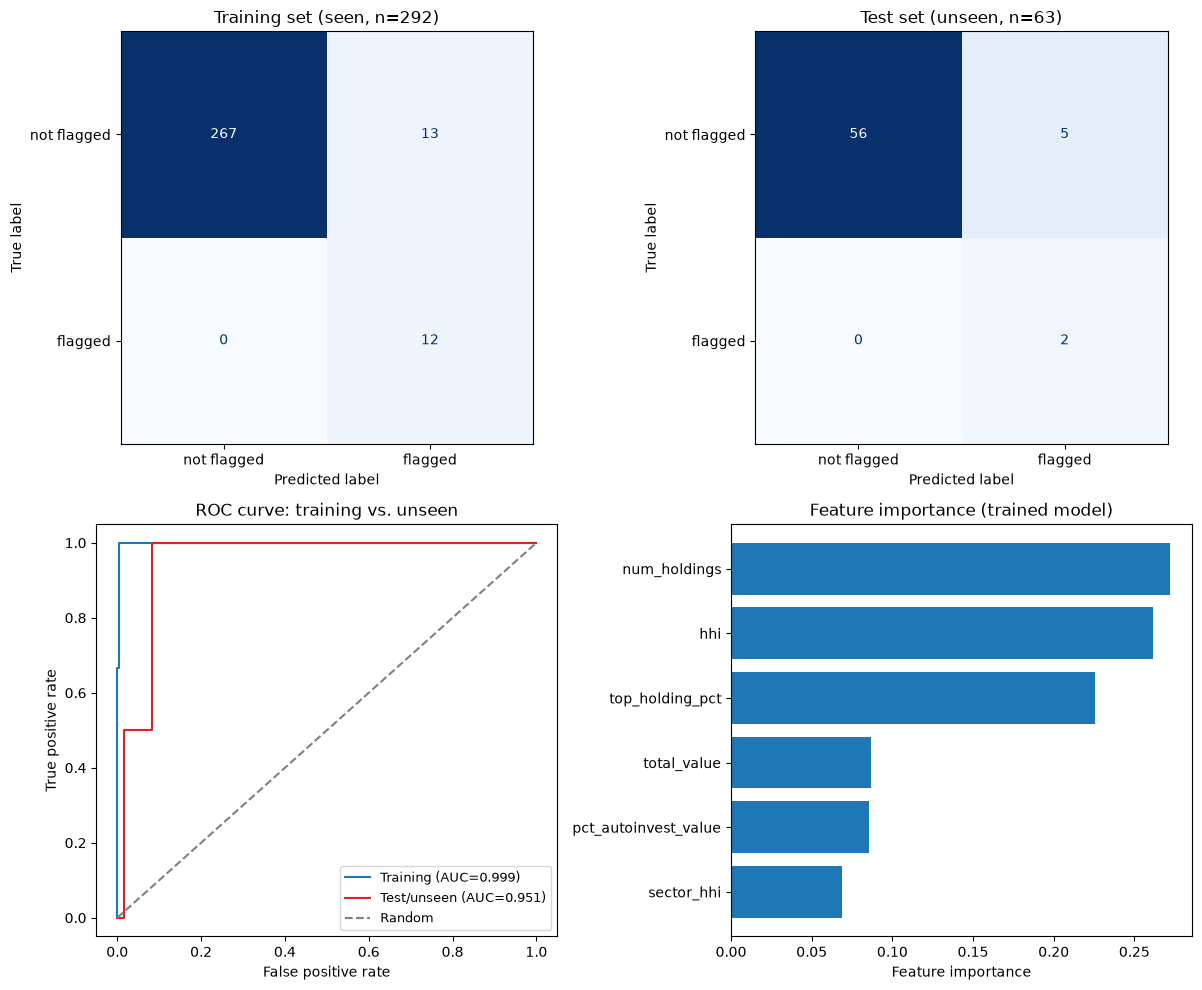

Test set (unseen) classification report:

              precision    recall  f1-score   support

 not flagged       1.00      0.92      0.96        61
     flagged       0.29      1.00      0.44         2

    accuracy                           0.92        63
   macro avg       0.64      0.96      0.70        63
weighted avg       0.98      0.92      0.94        63

Test set ROC-AUC: 0.951


In [89]:

y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]

y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: training confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay(cm_train, display_labels=["not flagged", "flagged"]).plot(
    ax=axes[0, 0], cmap="Blues", colorbar=False
)
axes[0, 0].set_title(f"Training set (seen, n={len(y_train)})")

# Top-right: test confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test, display_labels=["not flagged", "flagged"]).plot(
    ax=axes[0, 1], cmap="Blues", colorbar=False
)
axes[0, 1].set_title(f"Test set (unseen, n={len(y_test)})")

# Bottom-left: ROC curves, train vs test
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
axes[1, 0].plot(fpr_train, tpr_train, label=f"Training (AUC={auc(fpr_train, tpr_train):.3f})", color="#1f77b4")
axes[1, 0].plot(fpr_test, tpr_test, label=f"Test/unseen (AUC={auc(fpr_test, tpr_test):.3f})", color="#d62728")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
axes[1, 0].set_xlabel("False positive rate")
axes[1, 0].set_ylabel("True positive rate")
axes[1, 0].set_title("ROC curve: training vs. unseen")
axes[1, 0].legend(loc="lower right", fontsize=9)

# Bottom-right: feature importance
importances = pd.Series(model.feature_importances_, index=X_cols).sort_values()
axes[1, 1].barh(importances.index, importances.values, color="#1f77b4")
axes[1, 1].set_xlabel("Feature importance")
axes[1, 1].set_title("Feature importance (trained model)")

plt.tight_layout()
fig.savefig("results_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Test set (unseen) classification report:\n")
print(classification_report(y_test, y_test_pred, target_names=["not flagged", "flagged"]))
print("Test set ROC-AUC:", round(roc_auc_score(y_test, y_test_proba), 3))

### Results interpretation

**Training set (seen, n=292):** the model correctly flags 12/12 training-set positives (0 false negatives), with 13 false positives out of 280 negatives. Training ROC-AUC is 0.999. This is expected and not a concern on its own, as it reflects fitted performance on data the model was trained on, not a claim about generalisation, which is what the test set below checks.

**Test set (unseen, n=63, 2 positives):** the model correctly flags both of the 2 true positive clients (100% recall), with 5 false positives out of 61 negatives (precision = 0.29, ROC-AUC = 0.951). No concentration-risk clients were missed on this held-out set.

This pattern, 100% recall paired with lower precision, is a reasonable tradeoff for this specific business problem. STADIOEquities is screening clients for a potential suitability issue (holding a concentrated portfolio while the client's stated risk appetite is low); the cost of a missed flag (a genuinely at-risk client never gets reviewed) is substantially higher than the cost of a false flag (an analyst spends a few minutes reviewing a client who turns out to be fine). A model that catches every true case at the expense of a handful of extra manual reviews is well suited to this kind of triage use, more so than a model tuned to maximise precision.

The test set holds only 2 positive cases, so this result should be read as a positive early signal rather than a precise, stable estimate of real-world recall. With n=2, missing either case would have moved recall from 100% to 50%; the appropriate next step before any production use is validating against a larger, more recent sample as STADIOEquities' client base and complaint history grow.

**Feature importance:** `num_holdings`, `hhi`, and `top_holding_pct` are the three dominant drivers of the model's predictions, consistent with the Model Training discussion above. `total_value`, `pct_autoinvest_value`, and `sector_hhi` contribute smaller but non-trivial amounts, suggesting portfolio value and automated investing behaviour add some discriminating signal beyond the core concentration metrics, without dominating the decision.

Taken together with the Model Validation findings above (including the client 174 case, an extreme out-of-distribution example the validation set missed), these results support using the model as a first-pass screening tool with the recommended safety-net rule for extreme cases, rather than as a fully automated decision-maker.